## Modelo logístico (modelo de Verhulst)

**Modelo de Verhulst**:
\begin{equation}
\left\{\begin{aligned}&\frac{dP}{dt} = r_0 P\left(1-\frac{P}{P_s}\right),\quad t\geq t_0 \\
&P(t_0) = P_0\end{aligned}\right.
\end{equation}

Variáveis adimensionais:
\begin{equation}
p=\frac{P}{P_s},\quad \tau = r_0 (t-t_0).
\end{equation}

**Modelo de Verhulst** nas variáveis adimensionais:

\begin{equation}
\left\{\begin{aligned}&\frac{dp}{d\tau} = p(1-p),\quad\tau\geq 0 \\
&p(0) = p_0\end{aligned}\right.
\end{equation}

Solução analítica:
\begin{equation}
p(\tau) = \frac{p_0\exp(\tau)}{1+p_0(\exp(\tau)-1)}.
\end{equation}

Logo, nas variáveis dimensionais a solução é dada como
\begin{equation}
P(t) = \frac{P_0\exp(r_0 (t-t_0))}{1+\frac{P_0}{P_s}\left[\exp(r_0 (t-t_0))-1\right]}.
\end{equation}


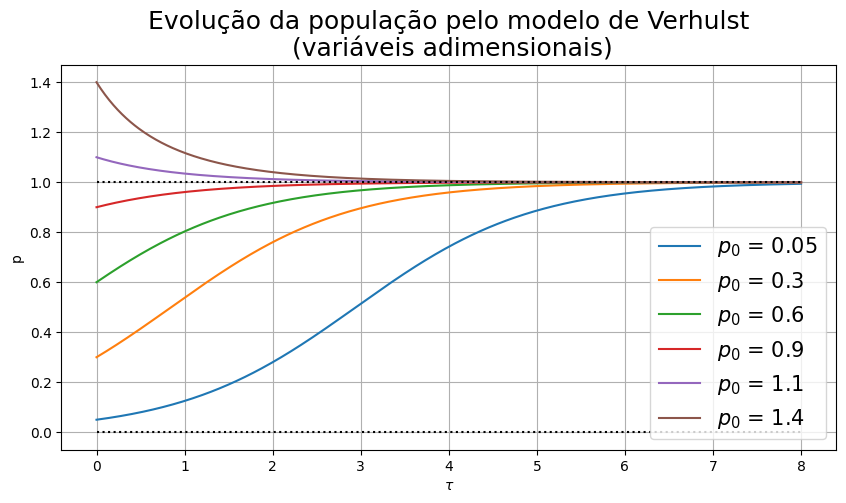

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tt = np.linspace(0, 8, 500)
p0 = [0.05, 0.3, 0.6, 0.9, 1.1, 1.4]


plt.figure(figsize=(10,5))
for p_0 in p0:
  p = p_0*np.exp(tt)/(1+p_0*(np.exp(tt)-1))
  plt.plot(tt, p, label=r'$p_0$ = '+str(p_0))

plt.plot([0,8], [1,1], ':k')
plt.plot([0,8], [0,0], ':k')
plt.legend(fontsize=15)

# Colocamos os nomes dos eixos
plt.xlabel(r'${\tau}$')
plt.ylabel('p')
plt.grid()

# Colocamos um título
plt.title(u'Evolução da população pelo modelo de Verhulst\n (variáveis adimensionais)', fontsize=18);

## Dados da população de Brasil e Taxa de Crescimento relativo

Período de 1960 até 2022 (Fonte:  [Censo IBGE - 2022](https://censo2022.ibge.gov.br/panorama/))

In [ ]:
import pandas as pd

#tempo em anos
tb = np.array([1872, 1890, 1900, 1920, 1940, 1950, 1960, 1970, 1980, 1991, 2000, 2010, 2022])
#População em milhões de pessoas
Pb = np.array([9.930478,  14.333915, 17.438434, 30.635605,  41.236315, 51.944397, 70.992343, 94.508583, 121.150573, 146.917459, 169.590693, 190.755799, 203.062512])
#Taxa de crescimento relativo
Rb1 = (Pb[1:]-Pb[:-1])/(tb[1:]-tb[:-1])/Pb[:-1]
Rb0 = np.concatenate((['--'], Rb1))
#Rb = np.array(['--', 0.02463480498, 0.02165855595, 0.03783932376, 0.01730129044, 0.02596760162, 0.03666987606, 0.03312503716, 0.02819002164, 0.01933498228, 0.01714737132, 0.01248011057, 0.005376294834])

dados = {'Ano': tb, 'População': Pb, 'TCR': Rb0}
#Criar o DataFrame
df = pd.DataFrame(dados)
# Oculta o índice
df.style.hide(axis='index')

display(df)


,Ano,População,TCR
0,1872,9.930478,--
1,1890,14.333915,0.02463480498007133
2,1900,17.438434,0.02165855594929928
3,1920,30.635605,0.03783932376037894
4,1940,41.236315,0.017301290442933957
5,1950,51.944397,0.025967601615226786
6,1960,70.992343,0.036669876059972364
7,1970,94.508583,0.03312503716069773
8,1980,121.150573,0.02819002164067997
9,1991,146.917459,0.01933498227712207


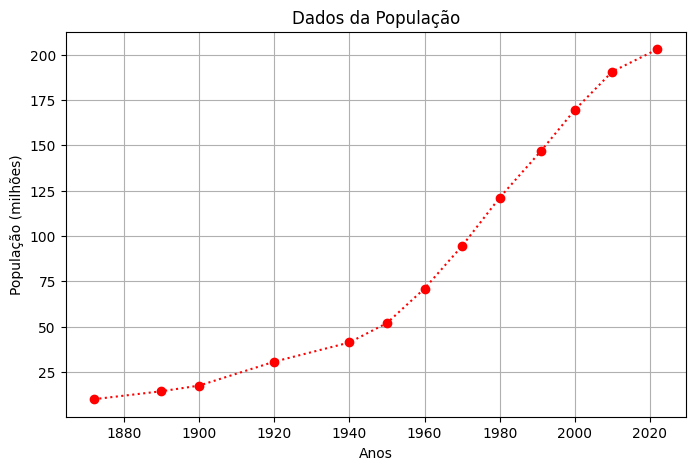

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel('Anos')
ax1.set_ylabel('População (milhões)')
ax1.plot(tb, Pb, 'r:o')
ax1.grid();
ax1.set_title(u'Dados da População', fontsize=12);

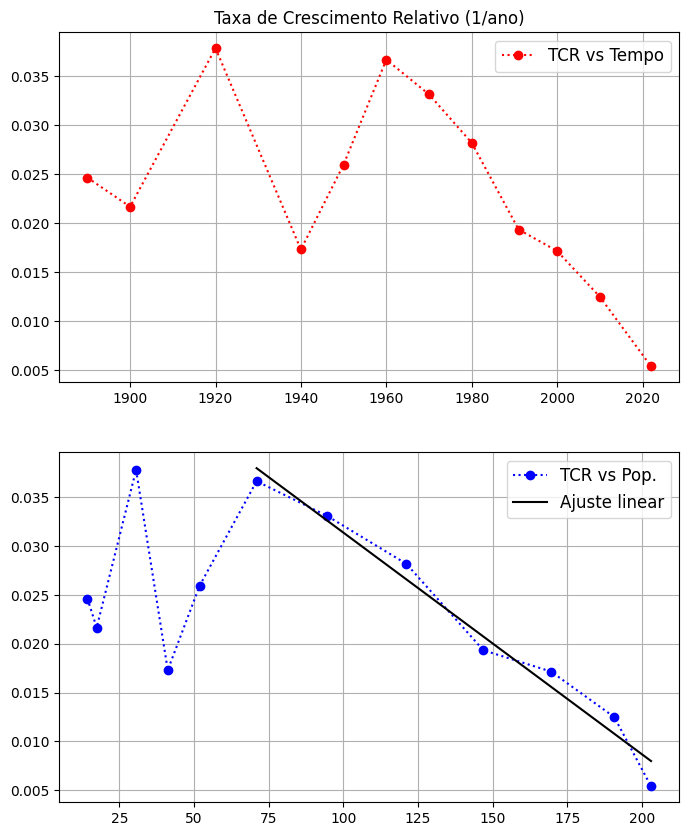

In [ ]:
#Ajuste da relação linear: Rb = aa[1] + aa[0]*Pb
ta = tb[6:]
Pa = Pb[6:]
Ra = Rb1[5:]
aa = np.polyfit(Pa, Ra, 1)

r0 = aa[1]
Ps = -aa[1]/aa[0]

#Figuras
fig, axs = plt.subplots(2,1,figsize=(8,10))
ta1 = tb[1:]
Pb1 = Pb[1:]

axs[0].set_title(u'Taxa de Crescimento Relativo (1/ano)', fontsize=12);
axs[0].plot(ta1, Rb1, 'r:o', label='TCR vs Tempo')
axs[0].grid();
axs[0].legend(fontsize=12)


axs[1].plot(Pb1, Rb1, 'b:o', label=r'TCR vs Pop.')
axs[1].plot(Pa, aa[0]*Pa+aa[1], '-k', label=r'Ajuste linear')
axs[1].grid();
axs[1].legend(fontsize=12);

Nas figuras acima mostramos as aproximações para as taxas de crescimento relativo $r(P) = r_0\left(1-\frac{P}{P_s}\right)$ calculadas em cada intervalo a partir dos dados.

Estas foram obtidas na forma $$r(P(t_i))\approx TCR_i = \frac{P(t_i) - P(t_i-\Delta t)}{(\Delta t)P(t_i)}  = \frac{P(t_i) - P(t_{i-1})}{(t_i-t_{i-1})P(t_i)}.$$

Na última figura também mostramos a reta correspondente ao ajuste linear dos dados do período de 1960 a 2022. Esse ajuste foi realizado pelo método dos mínimos quadrados usando a função [polyfit](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) do [NumPy](https://numpy.org/).

Os dados são ajustados por um polinômio de primeira ordem, ou seja, procurando $a_0$, $a_1$  que minimizam $$\sum_i[TCR_i - (a_0 P(t_i) + a_1)]^2.$$
Daí temos as seguintes estimativas
$$\widehat{r}_0 = a_1,\quad \widehat{P}_s=- \frac{a_1}{a_0}.$$

## Estimativa da população de Brasil com o modelo de Verhulst usando os parâmetros ajustados segundo a taxa de crescimento relativo

Uma vez obtidas as estimativas dos parâmetros $r_0$, $P_s$, podemos aferir a qualidade dos resultados do modelo calculando o **erro quadrático médio** ($EQM$)
$$EQM = \left[\frac{1}{D}\sum_{i=1}^D \left(P(t_i) - f_V(t_i, \widehat{r}_0,\widehat{P}_s)\right)^2\right]^{1/2}$$
onde $D$ é a quantidade de dados utilizados na estimativa (associados ao período de 1960 à 2022),  $\widehat{r}_0$, $\widehat{P}_s$ representam as estimativas dos parâmetros e $f_V$ é a solução do modelo de Verhulst apresentada na primeira seção.

Adicionalmente consideramos o erro quadrático médio normalizado $EQM_n = \frac{EQM}{P_0}$.

Taxa de cresc. rel. máximo = 0.0541 1/ano
Capacidade de suporte = 2.38e+02 milhões de pessoas
Erro quad. médio = 1.920e+02
Erro quad. médio normalizado = 3.810e-02


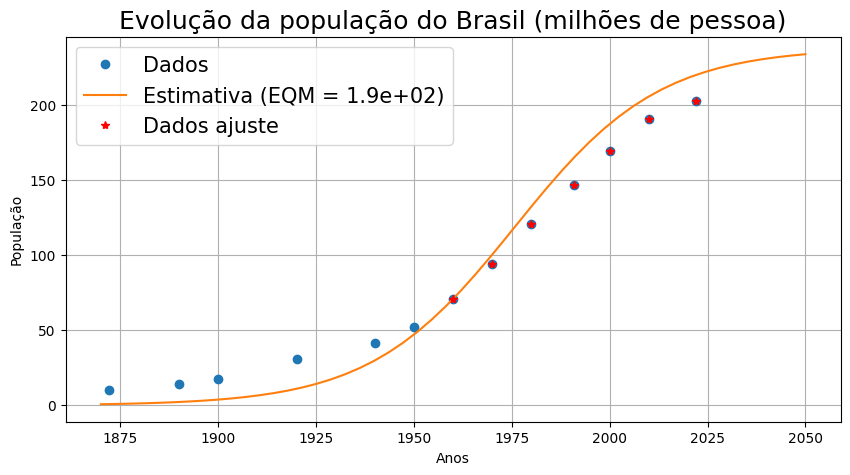

In [ ]:
#Dados iniciais do intervalo de interesse
P0 = Pa[0]
t0 = ta[0]

p_0 = P0/Ps
#Solução do modelo de Verhulst (tempo adimensional)
pb = lambda t: P0*np.exp(t)/(1+p_0*(np.exp(t)-1))

tta = np.linspace(1870, 2050)
tt = r0*(tta-t0)

print( f'Taxa de cresc. rel. máximo = {r0:.4f} 1/ano')
print( f'Capacidade de suporte = {Ps:.2e} milhões de pessoas')

Erro_V1 = np.mean( (Pa - pb(r0*(ta-t0)))**2 )
Erro_V1n = np.mean( ((Pa - pb(r0*(ta-t0)))/P0)**2 )
print( f'Erro quad. médio = {Erro_V1:.3e}')
print( f'Erro quad. médio normalizado = {Erro_V1n:.3e}')

plt.figure(figsize=(10,5))
plt.plot(tb, Pb, 'o', label='Dados')
plt.plot(tta, pb(tt), label='Estimativa '+'(EQM = {:.1e})'.format(Erro_V1));
plt.plot(ta, Pa, 'r*', label='Dados ajuste')
plt.grid();

plt.xlabel('Anos')
plt.ylabel('População')
plt.legend(fontsize=15)
plt.title(u'Evolução da população do Brasil (milhões de pessoa)', fontsize=18);

O que podemos fazer para melhorar a qualidade das estimativas?

Na próxima seção mostramos como estimar os parâmetros $r_0$ e $P_s$, diretamente dos dados disponíveis.

## Estimativa da população de Brasil com o modelo de Verhulst ajustando os parâmetros da função solução

Para estimar os parâmetros $r_0$ e $P_s$, observando que a solução do modelo de Verhulst é uma função conhecida pelo que podemos usar diretamente os dados disponíveis.

De fato, aplicando o **método dos mínimos quadrados não linear** conseguiremos estimar os parâmetros $r_0$ e $P_s$.

Para isso há que minimizar a função objetivo $$f_{obj}(r_0, P_s) = \sum_{i}\left[ P(t_i) - f_V(t_i, r_0, P_s)\right]^2.$$

Para implementar esse procedimento utilizamos a função [curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) do [Scipy](https://scipy.org/).

Taxa de cresc. rel. máximo = 0.0449 1/ano
Capacidade de suporte = 2.34e+02 milhões de pessoas
Erro quad. médio = 2.025e+00
Erro quad. médio normalizado = 4.018e-04


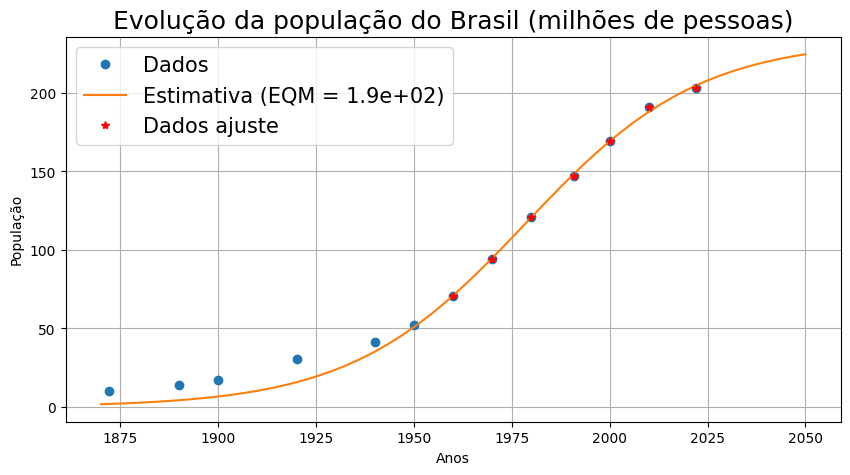

In [ ]:
from scipy.optimize import curve_fit

P0 = Pa[0]
t0 = ta[0]
pv = lambda t, r0, Ps: P0*np.exp(r0*t)/(1+P0/Ps*(np.exp(r0*t)-1))

av, pconv = curve_fit( pv, ta-t0, Pa, p0 = np.array([r0, Ps]))

r01 = av[0]
Ps1 = av[1]

print( f'Taxa de cresc. rel. máximo = {r01:.4f} 1/ano')
print( f'Capacidade de suporte = {Ps1:.2e} milhões de pessoas')

Erro_V = np.mean( (Pa - pv(ta-t0, r01, Ps1))**2 )
Erro_Vn = np.mean( ((Pa - pv(ta-t0, r01, Ps1))/P0)**2 )
print( f'Erro quad. médio = {Erro_V:.3e}')
print( f'Erro quad. médio normalizado = {Erro_Vn:.3e}')

plt.figure(figsize=(10,5))
plt.plot(tb, Pb, 'o', label='Dados')
plt.plot(tta, pv(tta-t0, r01, Ps1), label='Estimativa '+'(EQM = {:.1e})'.format(Erro_V1));
plt.plot(ta, Pa, 'r*', label='Dados ajuste')
plt.grid();

plt.xlabel('Anos')
plt.ylabel('População')
plt.legend(fontsize=15)
plt.title(u'Evolução da população do Brasil (milhões de pessoas)', fontsize=18);

Comparando os valores do erro quadrático médio observamos que as estimativas apresentadas nesta seção são bem melhores que a da seção anterior. Isto acontece porque neste último método não é necessário obter aproximações das taxas de crescimento relativo, evitando-se, dessa forma os erros associados a essas aproximações.